# 📈 Forecasting de revenue - Hapy Cow Ice Cream


## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---


## Contexto e introducción

En el caso de Happy Cow Ice Cream, se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Debido al alto nivel de ruido y variabilidad en la información diaria, el análisis se enfocará en construir un forecast semanal, permitiendo identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes, como la limitada cantidad de datos disponibles y la influencia de factores externos en la demanda, lo que hace necesario complementar el modelado con un análisis exploratorio cuidadoso 🧠.

## 🧩 Enunciado

Como consultor externo, se le solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes, generando pronósticos **semanales (cuatro semanas adelante)**. Los datos se encuentran en el archivo `ice_cream_data_daily.csv`, que incluye:

- **Product**
- **Date_clean**
- **Revenue**

El objetivo es producir pronósticos confiables que apoyen la planificación, reduzcan el desperdicio y mejoren la eficiencia operativa. 📊🤝


In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data = pd.read_csv("ice_cream_data_daily.csv", delimiter=',', encoding="utf8")

# ✅ Criterios de evaluación – Descripción

1) **Exploración y limpieza de los datos**  
Realiza una exploración clara de la serie y sus variables (tendencias, estacionalidad, valores atípicos, faltantes). Limpia y estandariza formatos (fechas, unidades, precios) y deja trazabilidad de las decisiones tomadas para garantizar un conjunto de datos listo para modelar.

2) **Modelo “base”, métrica y separación temporal**  
Implementa un modelo base razonable para tu problema (p. ej., media móvil) y evalúalo con una métrica coherente con el negocio (MAE, RMSE o MAPE). Separa correctamente entrenamiento y test respetando la temporalidad, evitando cualquier fuga de información.

3) **Modelo avanzado para mejorar predicciones**  
Construye un modelo más sofisticado (ARIMA/SARIMA/SARIMAX, Prophet, ETS o un enfoque de ML con rasgos temporales/exógenas) y justifica su elección. Demuestra mejora frente al modelo base usando la misma ventana de evaluación y la misma métrica.

4) **Uso del modelo: predicción 4 semanas adelante**  
Selecciona un modelo ganador y genera un pronóstico operativo a **4 semanas** (multi‐paso). Entrega las predicciones en una tabla y un gráfico del horizonte, idealmente con intervalos de confianza y una breve guía de cómo reproducir el proceso.


>## Preguntas pendientes
>* Deberíamos tener en cuenta la estructura de precios diferenciados?
>* Por qué doble scoop o triple scoop aparecen negativos?
>* Cómo tratar los outliers? Deberíamos detectar si los ourliers se deben a las promociones? En caso de que se debería hacer? Eliminarlos?


# Punto 1

## Analisis Inicial

In [2]:
data.info()
data.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 19032 entries, 0 to 19031
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Product     19032 non-null  str    
 1   Date_clean  19032 non-null  str    
 2   Revenue     19032 non-null  float64
dtypes: float64(1), str(2)
memory usage: 446.2 KB


,Product,Date_clean,Revenue
count,19032,19032,19032.000000
unique,104,183,NaN
top,1 Topping,2017-04-01,NaN
freq,183,104,NaN
mean,NaN,NaN,14.390343
std,NaN,NaN,46.504922
min,NaN,NaN,-884.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,0.000000
75%,NaN,NaN,0.000000


In [3]:
data.duplicated().sum()

np.int64(0)

>* Hay mucha variación el el revenue. El revenue tiene una media de 14.39 dolares? con una desviación estandar de 46.50. Si asumimos normalidad (se puede?), en la mayoría de los casos, cada producto diaramente genera un revenue entre los 0 y los 60 dolares. Hay que tener en cuenta los valores negativos
>* Hay valores negativos (Revisado)
>* Hay 104 productos únicos, son demasiados (Revisado)
>* El tipo de dato de la fecha es str no datetime (Revisado)
>* En un principio parece no haber valores nulos (Revisado)
>* Teniendo en cuenta la media y la desviación estandar vale la pena revisar el valor mínimo (-884), máximo (806) y más outliers 

## Revisiones

### Valores negativos

In [4]:
# Mostrar productos ordenados por revenue de forma ascendente
data.groupby('Product')['Revenue'].sum().sort_values(ascending=True)

Product
Double Scoop ST                     -9802.00000
Double Scoop Staff                  -3930.00000
Double Scoop                        -1440.00000
Triple Scoop ST                     -1118.00000
Free Scoop Grassroot                 -910.00000
Asia Research Free Scoop             -858.00000
Building Promotion                   -728.00000
Finger B 100                         -720.00000
Registration day $20                 -708.00000
Gift Voucher ST                      -390.00000
Triple Scoop Staff                   -342.00000
Staff Off -$2                        -298.00000
Triple Scoop                         -280.00000
Gift coupon 3 cone                   -261.00000
Stamp Card REDEEM ST                 -208.00000
ZALORA Ecoupon Buy 1 Get 1 Scoop      -26.00000
Single Scoop Staff                      0.00000
ZALORA $30 Spent Coupon                 0.00000
Single Scoop                            0.00000
Tub Staff                               0.00000
Single Scoop ST                 

>* Esto es un reflejo directo de las perdidas generadas a partir de los decuentos, promociones y diversas estrategias para atraer clientes como Building Promotion, Registration Day $20, Staff Off -$2, Stamp Card Redeem ST
>* Hace falta información para saber por qué Double Scoop y Tripe Scoop aparecen negativos

### Cantidad de productos únicos

In [5]:
data['Product'].value_counts()

Product
1 Topping                           183
1 Topping Staff                     183
1 Toppings St                       183
3 Topping                           183
3 Topping Staff                     183
Apricot                             183
Apricot ST                          183
Apricot Staff                       183
Asia Research Free Scoop            183
Banana Caramel  /                   183
Banana Caramel St                   183
Banana Staff                        183
Building Promotion                  183
Chai Tea                            183
Chai Tea Staff                      183
Chai Tea st                         183
Cherry Alm Staff                    183
Cherry Almond                       183
Cherry Almond Fudge st              183
Chocoate Cookies                    183
Chocolate                           183
Chocolate St                        183
Chocolate Staff                     183
Coffee                              183
Coffee  St                      

>* producto_x, producto_x st y producto_x staff, son productos diferentes? Investigando el documento se plantea que este se debe a que la universidad de Hong Kong tiene una estructura de precios diferenciada cobrando diferente a los visitantes studiantes y staff (st -> precio estudiantes, staff -> precio staff). por ahora se plantea agrupar los valores por producto 
>* se observa que para todos los productos hay 183 registros, es decir el registro diaro del revenue por producto a través de más o menos 6 meses

In [6]:
# Elimina "Staff" y "St" (sin importar mayúsculas) al final de los nombres
data['Product_Clean'] = data['Product'].str.replace(r'\s+(Staff|ST|st|St)$', '', regex=True).str.strip()

# Elimina cualquier barra ("/") al final de los nombres, junto con espacios adicionales.
data['Product_Clean'] = data['Product_Clean'].str.replace(r'\s+(/)$', '', regex=True).str.strip()

# Agrupa por día y producto, sumando la columna de ingresos
revenue_por_dia = data.groupby(['Date_clean', 'Product_Clean'])['Revenue'].sum().reset_index()

revenue_por_dia['Date_clean'] = pd.to_datetime(revenue_por_dia['Date_clean'], errors='coerce')

revenue_por_dia['Product_Clean'].value_counts()


revenue_por_dia.info()
revenue_por_dia.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 10797 entries, 0 to 10796
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date_clean     10797 non-null  datetime64[us]
 1   Product_Clean  10797 non-null  str           
 2   Revenue        10797 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 253.2 KB


,Date_clean,Product_Clean,Revenue
count,10797,10797,10797.000000
unique,NaN,59,NaN
top,NaN,1 Topping,NaN
freq,NaN,183,NaN
mean,2017-07-01 00:00:00,NaN,25.366028
min,2017-04-01 00:00:00,NaN,-884.000000
25%,2017-05-16 00:00:00,NaN,0.000000
50%,2017-07-01 00:00:00,NaN,0.000000
75%,2017-08-16 00:00:00,NaN,7.000000
max,2017-09-30 00:00:00,NaN,846.000000


>* El número de diferentes productos disminuyó de 104 a 59
>* El número de registros paso de 19032 a 10797

In [7]:
# Actualizar la variable 'data' con el nuevo DataFrame 'revenue_por_dia'
data_original = data.copy()
data = revenue_por_dia.copy()

In [8]:
data['Product_Clean'].value_counts()

Product_Clean
1 Topping                           183
1 Toppings                          183
3 Topping                           183
Apricot                             183
Asia Research Free Scoop            183
Banana                              183
Banana Caramel                      183
Building Promotion                  183
Chai Tea                            183
Cherry Alm                          183
Cherry Almond                       183
Cherry Almond Fudge                 183
Chocoate Cookies                    183
Chocolate                           183
Coffee                              183
Cus IC Sand                         183
Cus. IC Sand                        183
Double Scoop                        183
Finger B 100                        183
Free Scoop Grassroot                183
Gift Voucher                        183
Gift Voucher Reg                    183
Gift coupon 3 cone                  183
Ginger                              183
Granola                   

### Tratamiento de valores nulos o faltantes

In [9]:
# 1. Preparación previa (Asegúrate de tener Date_clean como datetime)
data['Date_clean'] = pd.to_datetime(data['Date_clean'])

# 2. Definir el rango ideal global (del primer al último día de toda la base)
rango_global = pd.date_range(start=data['Date_clean'].min(), end=data['Date_clean'].max(), freq='D')

# 3. Diccionario para guardar los resultados
reporte_faltantes = {}

# 4. Agrupar por producto y comparar cada uno contra el rango global
for producto, grupo in data.groupby('Product_Clean'):
    # Sacamos las fechas únicas que tiene este producto específico
    fechas_producto = grupo['Date_clean'].unique()
    
    # Encontramos la diferencia
    faltantes = rango_global.difference(fechas_producto)
    
    # Guardamos en el reporte
    reporte_faltantes[producto] = {
        'cantidad': len(faltantes),
        'fechas': faltantes
    }

# 5. Mostrar resultados de forma ordenada
for producto, info in reporte_faltantes.items():
    if info['cantidad'] > 0:
        print(f"Producto: {producto}")
        print(f" - Días faltantes: {info['cantidad']}")
        # Mostramos las primeras 5 fechas para no saturar la pantalla
        print(f" - Primeras fechas faltantes: {info['fechas'][:5].strftime('%Y-%m-%d').tolist()}")
        print("-" * 30)

>* Como en el análisis inicial no se vieron valores nulos a simple vista, se buscó por días faltantes desde el primero hasta el último día para cada producto y no se encontro ninguno

### Tratamiento de outliers

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10797 entries, 0 to 10796
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date_clean     10797 non-null  datetime64[us]
 1   Product_Clean  10797 non-null  str           
 2   Revenue        10797 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 253.2 KB


In [11]:
revenue_total = (data
    .groupby('Date_clean')['Revenue']
    .sum()
    .reset_index()
    .set_index('Date_clean')
    .asfreq('D')) # Asegura que el índice sea de tipo datetime y tenga frecuencia diaria

productos_promocion = [ # Lista de productos asociados a promociones o descuentos
    'Double Scoop', 'Triple Scoop', 'Free Scoop Grassroot',
    'Asia Research Free Scoop', 'Building Promotion',
    'Finger B 100', 'Registration day $20', 'Gift Voucher',
    'Gift coupon 3 cone', 'Staff Off -$2', 'Stamp Card REDEEM',
    'ZALORA Ecoupon Buy 1 Get 1 Scoop', 'ZALORA $30 Spent Coupon'
]

data['es_promocion'] = data['Product_Clean'].isin(productos_promocion) # Crea una nueva columna booleana que indica si el producto es parte de una promoción

revenue_real = data[~data['es_promocion']].groupby('Date_clean')['Revenue'].sum()
revenue_promo = data[data['es_promocion']].groupby('Date_clean')['Revenue'].sum()


# Descomposición STL para detectar outliers en la serie de ingresos reales
from statsmodels.tsa.seasonal import STL
import numpy as np

stl = STL(revenue_real, period=7, robust=True)
result = stl.fit()

residuo = result.resid
mad = np.median(np.abs(residuo - residuo.median()))  # MAD robusto
umbral = 3 * 1.4826 * mad  # equivalente a ~3σ bajo normalidad

outliers_stl = residuo[np.abs(residuo) > umbral]

# ¿Los días con outlier positivo coinciden con descuentos o eventos especiales?
descuento_diario = revenue_promo.abs()  # magnitud de descuentos por día
outlier_flag = pd.Series(False, index=revenue_real.index)
outlier_flag[outliers_stl.index] = True

pd.crosstab(outlier_flag, descuento_diario > descuento_diario.quantile(0.75),
            rownames=['Es outlier'], colnames=['Día de alto descuento'])

Día de alto descuento,False,True
Es outlier,,
False,118,39
True,19,7


> Se comprobó que no hay una relación entre los outliers y los días con alto descuento ya que la proporción de outliers tanto en los días de alto descuento como de los que no, es más o menos la misma 1/6

Serie semanal: 27 semanas
Período: 2017-04-02 → 2017-10-01

Revenue semanal promedio: HKD 10,959
Revenue semanal mínimo:   HKD 2,439
Revenue semanal máximo:   HKD 16,362


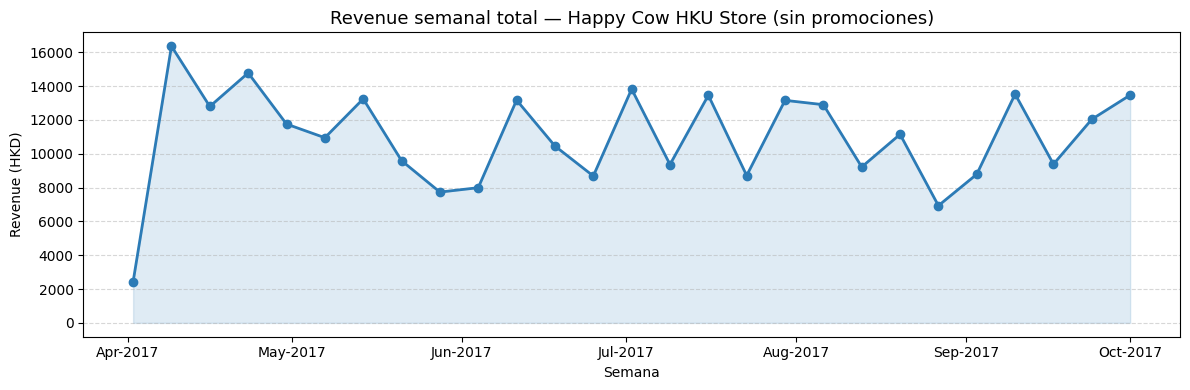

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
 
# --- Reconstruir serie de revenue real (sin promociones) ---
productos_promocion = [
    'Double Scoop', 'Triple Scoop', 'Free Scoop Grassroot',
    'Asia Research Free Scoop', 'Building Promotion',
    'Finger B 100', 'Registration day $20', 'Gift Voucher',
    'Gift coupon 3 cone', 'Staff Off -$2', 'Stamp Card REDEEM',
    'ZALORA Ecoupon Buy 1 Get 1 Scoop', 'ZALORA $30 Spent Coupon'
]
 
# 'data' ya fue limpiado en el Punto 1 (contiene Date_clean, Product_Clean, Revenue)
data_real = data[~data['Product_Clean'].isin(productos_promocion)].copy()
 
# Agregar revenue total diario
revenue_diario = (data_real
    .groupby('Date_clean')['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Date_clean': 'ds', 'Revenue': 'y'})
    .sort_values('ds'))
 
# Resamplear a semanal (suma de lunes a domingo, etiqueta el domingo)
revenue_semanal = (revenue_diario
    .set_index('ds')
    .resample('W')
    .sum()
    .reset_index())
 
print(f"Serie semanal: {len(revenue_semanal)} semanas")
print(f"Período: {revenue_semanal['ds'].min().date()} → {revenue_semanal['ds'].max().date()}")
print(f"\nRevenue semanal promedio: HKD {revenue_semanal['y'].mean():,.0f}")
print(f"Revenue semanal mínimo:   HKD {revenue_semanal['y'].min():,.0f}")
print(f"Revenue semanal máximo:   HKD {revenue_semanal['y'].max():,.0f}")
 
# Gráfico de la serie completa
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(revenue_semanal['ds'], revenue_semanal['y'], marker='o', color='#2c7bb6', linewidth=2)
ax.fill_between(revenue_semanal['ds'], revenue_semanal['y'], alpha=0.15, color='#2c7bb6')
ax.set_title('Revenue semanal total — Happy Cow HKU Store (sin promociones)', fontsize=13)
ax.set_xlabel('Semana')
ax.set_ylabel('Revenue (HKD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Punto 2

Serie semanal: 27 semanas
Período: 2017-04-02 → 2017-10-01

Revenue semanal promedio: HKD 10,959
Revenue semanal mínimo:   HKD 2,439
Revenue semanal máximo:   HKD 16,362


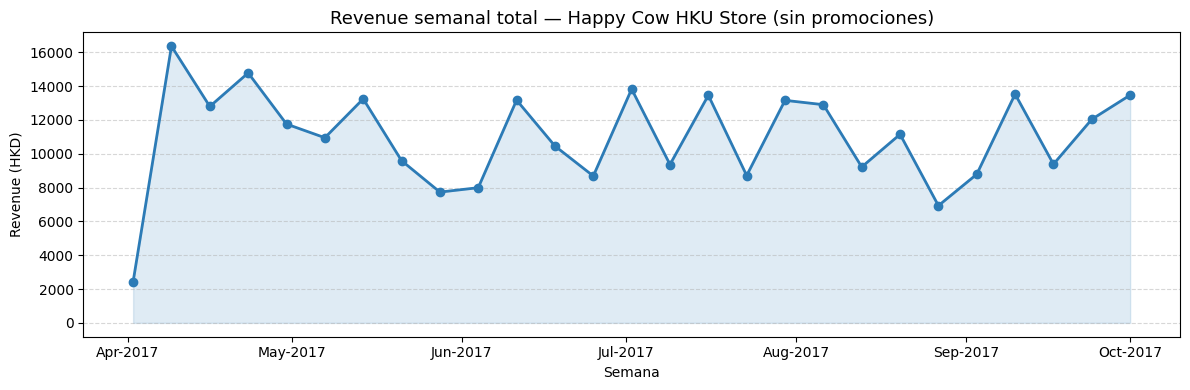

In [ ]:
# =============================================================================
# PUNTO 2 — Modelo Base: Media Móvil + Separación Temporal Train/Test
# =============================================================================
 
# ─────────────────────────────────────────────────────────────────────────────
# 2.1 Separación temporal (últimas 4 semanas = test)
# ─────────────────────────────────────────────────────────────────────────────
 
HORIZONTE = 4  # semanas a predecir (y a reservar para test)
 
train = revenue_semanal.iloc[:-HORIZONTE].copy()
test  = revenue_semanal.iloc[-HORIZONTE:].copy()
 
print(f"Train: {len(train)} semanas ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test:  {len(test)} semanas  ({test['ds'].min().date()} → {test['ds'].max().date()})")
 
# ─────────────────────────────────────────────────────────────────────────────
# 2.2 Modelo Base — Media Móvil de 4 semanas (ventana = últimas 4 obs. de train)
# Justificación: benchmark simple, sin parámetros, fácil de explicar al negocio.
# Predice siempre el promedio de las últimas 4 semanas conocidas.
# ─────────────────────────────────────────────────────────────────────────────
 
VENTANA_MA = 4
 
# La predicción base es constante: promedio de las últimas 4 semanas del train
pred_base = train['y'].rolling(VENTANA_MA).mean().iloc[-1]
pred_base_series = pd.Series([pred_base] * HORIZONTE, index=test.index)
 
print(f"\nPredicción Media Móvil ({VENTANA_MA} semanas): HKD {pred_base:,.0f} por semana")
 
# ─────────────────────────────────────────────────────────────────────────────
# 2.3 Métricas de evaluación
# ─────────────────────────────────────────────────────────────────────────────
 
def calcular_metricas(y_real, y_pred, nombre_modelo):
    mae  = np.mean(np.abs(y_real - y_pred))
    rmse = np.sqrt(np.mean((y_real - y_pred)**2))
    # MAPE: excluir ceros para evitar división por cero
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    print(f"\n📊 {nombre_modelo}")
    print(f"   MAE  = HKD {mae:,.0f}")
    print(f"   RMSE = HKD {rmse:,.0f}")
    print(f"   MAPE = {mape:.1f}%")
    return {'modelo': nombre_modelo, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
 
metricas_base = calcular_metricas(
    test['y'].values,
    pred_base_series.values,
    f'Media Móvil {VENTANA_MA} semanas'
)
 
# ─────────────────────────────────────────────────────────────────────────────
# 2.4 Gráfico Train / Test / Predicción Base
# ─────────────────────────────────────────────────────────────────────────────
 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train['ds'], train['y'], marker='o', label='Train', color='steelblue')
ax.plot(test['ds'],  test['y'],  marker='o', label='Test (real)', color='green')
ax.plot(test['ds'],  pred_base_series.values, marker='s', linestyle='--',
        label=f'Predicción Base (MA {VENTANA_MA})', color='orange')
ax.axvline(test['ds'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Inicio test')
ax.set_title('Separación Train/Test — Modelo Base (Media Móvil)', fontsize=13)
ax.set_ylabel('Revenue (HKD)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Punto 3

# Punto 4